# DB1:RelE REMD — Analysis

## Imports

In [1]:
%matplotlib inline
import os, sys
from collections import Counter

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import MDAnalysis as mda
from MDAnalysis.analysis import rms
from sklearn.cluster import KMeans


## Configuration

In [2]:
# ── Trajectory ───────────────────────────────────────────────────────────────
TRAJS = {
    "bound_start": {
        "top":   "DB1_bound_unbound_300K_stripped.pdb",
        "xtc":   "DB1_bound_unbound_300K_stripped.xtc",
        "label": "Bound-start",
        "color": "#1f77b4",
    }
}

# ── References ───────────────────────────────────────────────────────────────
REF_ALONE       = "DB1_unbound.pdb"
REF_BOUND       = "DB1_bound.pdb"
REF_BOUND_CHAIN = "A"
BACKBONE_SEL    = "backbone"

# ── Equilibration / clustering ──────────────────────────────────────────────
BURNIN_FRAMES = 5000
K_RANGE       = list(range(2, 16))
K_OVERRIDE    = None     # set to an int to bypass elbow selection

# ── Output folder ────────────────────────────────────────────────────────────
OUT_DIR    = "DB1_output"
os.makedirs(OUT_DIR, exist_ok=True)
OUT_PREFIX = os.path.join(OUT_DIR, "DB1")

# ── Constants ────────────────────────────────────────────────────────────────
kT         = 0.592    # kcal/mol at 298 K
BLOCK_SIZE = 200      # frames per block for the equilibration trace

print(f"Config loaded. Outputs → {OUT_DIR}/")


Config loaded. Outputs → DB1_output/


## 1. Load references and trajectory

In [3]:
# ── Load references ─────────────────────────────────────────────────────────
ref_alone = mda.Universe(REF_ALONE)
ref_bound = mda.Universe(REF_BOUND)

BOUND_CHAIN_SEL = None
for kw in ["chainID", "segid"]:
    test = f"{BACKBONE_SEL} and {kw} {REF_BOUND_CHAIN}"
    if len(ref_bound.select_atoms(test)) > 0:
        BOUND_CHAIN_SEL = test
        break
assert BOUND_CHAIN_SEL, "Cannot select chain A from bound reference"
print(f"Bound chain selector: {BOUND_CHAIN_SEL}")

# ── Load trajectory ─────────────────────────────────────────────────────────
universes = {}
for tkey, tinfo in TRAJS.items():
    u = mda.Universe(tinfo["top"], tinfo["xtc"])
    print(f"  {tkey}: {len(u.trajectory)} frames, {len(u.atoms)} atoms")
    universes[tkey] = u

u0 = list(universes.values())[0]
traj_resids = sorted(u0.select_atoms(BACKBONE_SEL).residues.resids)
ref_resids  = sorted(ref_alone.select_atoms(BACKBONE_SEL).residues.resids)

# Detect extra N-terminal Met
traj_first_resname = u0.select_atoms(
    f"{BACKBONE_SEL} and resid {traj_resids[0]}").residues[0].resname

TRAJ_OFFSET = 0
if len(traj_resids) == len(ref_resids) + 1 and traj_first_resname == "MET":
    TRAJ_OFFSET = 1
    print(f"Extra N-terminal Met detected (offset = {TRAJ_OFFSET})")
else:
    print(f"Trajectory and reference numbering match (offset = 0)")


Bound chain selector: backbone and chainID A
  bound_start: 49999 frames, 1307 atoms
Trajectory and reference numbering match (offset = 0)


## 2. Build selections — full protein backbone

In [4]:
traj_start = traj_resids[0] + TRAJ_OFFSET
traj_end   = traj_resids[-1]
ref_start, ref_end = ref_resids[0], ref_resids[-1]

TRAJ_SEL      = f"{BACKBONE_SEL} and resid {traj_start}:{traj_end}"
REF_ALONE_SEL = f"{BACKBONE_SEL} and resid {ref_start}:{ref_end}"
REF_BOUND_SEL = f"{BOUND_CHAIN_SEL} and resid {ref_start}:{ref_end}"

# Reference coordinates + alone↔bound RMSD baseline
ref_alone_pos = ref_alone.select_atoms(REF_ALONE_SEL).positions.copy()
ref_bound_pos = ref_bound.select_atoms(REF_BOUND_SEL).positions.copy()
refref_rmsd   = rms.rmsd(ref_alone_pos, ref_bound_pos,
                         center=True, superposition=True)

# Verify atom counts
nt = len(u0.select_atoms(TRAJ_SEL))
na, nb_ = len(ref_alone_pos), len(ref_bound_pos)
print(f"Atom counts — traj: {nt}, alone: {na}, bound: {nb_}")
print(f"alone↔bound RMSD = {refref_rmsd:.2f} Å")
assert nt == na == nb_, "Atom count mismatch!"
print("Selections verified (full protein backbone).")


Atom counts — traj: 336, alone: 336, bound: 336
alone↔bound RMSD = 7.31 Å
Selections verified (full protein backbone).


## 3. Per-frame backbone RMSD to each reference


In [5]:
all_data = {}
for tkey, u in universes.items():
    print(f"\nProcessing {tkey}...")
    n_frames   = len(u.trajectory)
    rmsd_alone = np.zeros(n_frames)
    rmsd_bound = np.zeros(n_frames)
    time_ps    = np.zeros(n_frames)
    ag = u.select_atoms(TRAJ_SEL)

    for i, ts in enumerate(u.trajectory):
        if i % 10000 == 0:
            print(f"  Frame {i}/{n_frames}...", flush=True)
        time_ps[i]    = ts.time
        pos           = ag.positions.copy()
        rmsd_alone[i] = rms.rmsd(pos, ref_alone_pos, center=True, superposition=True)
        rmsd_bound[i] = rms.rmsd(pos, ref_bound_pos, center=True, superposition=True)

    eq_mask = np.arange(n_frames) >= BURNIN_FRAMES
    all_data[tkey] = {
        "rmsd_alone": rmsd_alone,
        "rmsd_bound": rmsd_bound,
        "time_ps":    time_ps,
        "eq_mask":    eq_mask,
        "n_frames":   n_frames,
        "n_eq":       int(eq_mask.sum()),
    }
    print(f"  Done. {n_frames} frames, {eq_mask.sum()} equilibrium.")



Processing bound_start...
  Frame 0/49999...
  Frame 10000/49999...
  Frame 20000/49999...
  Frame 30000/49999...
  Frame 40000/49999...
  Done. 49999 frames, 44999 equilibrium.


## 4. Per-residue Cα RMSF


In [6]:
ca_sel_traj = f"name CA and resid {traj_start}:{traj_end}"

rmsf_data = {}
for tkey, u in universes.items():
    print(f"RMSF for {tkey}...")
    traj_ca = u.select_atoms(ca_sel_traj)
    n_ca    = len(traj_ca)
    eq_mask = all_data[tkey]["eq_mask"]
    n_eq    = all_data[tkey]["n_eq"]

    ca_pos = np.zeros((n_eq, n_ca, 3))
    idx = 0
    for i, ts in enumerate(u.trajectory):
        if not eq_mask[i]:
            continue
        ca_pos[idx] = traj_ca.positions
        idx += 1

    # Iterative mean alignment (3 passes)
    mean_pos = ca_pos.mean(axis=0)
    for _ in range(3):
        aligned = np.zeros_like(ca_pos)
        for j in range(n_eq):
            mob = ca_pos[j] - ca_pos[j].mean(axis=0)
            ref = mean_pos - mean_pos.mean(axis=0)
            H = mob.T @ ref
            U, S, Vt = np.linalg.svd(H)
            d = np.sign(np.linalg.det(Vt.T @ U.T))
            R = Vt.T @ np.diag([1, 1, d]) @ U.T
            aligned[j] = mob @ R.T
        mean_pos = aligned.mean(axis=0)
        ca_pos = aligned

    rmsf = np.sqrt(((ca_pos - mean_pos) ** 2).sum(axis=2).mean(axis=0))
    rmsf_data[tkey] = {"rmsf": rmsf, "ca_positions": ca_pos}
    print(f"  {n_ca} Cα atoms, RMSF range: {rmsf.min():.2f}–{rmsf.max():.2f} Å")

ca_resids_ref = u.select_atoms(ca_sel_traj).resids - TRAJ_OFFSET
print("Done.")


RMSF for bound_start...
  84 Cα atoms, RMSF range: 4.27–15.00 Å
Done.


## Plotting helpers

In [7]:
plt.rcParams.update({
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
})

XLAB_DELTA = r"RMSD$_\mathrm{bound}$ − RMSD$_\mathrm{unbound}$ (Å)"


def bold_ticks(ax):
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")


## 5. Per-residue Cα RMSF plot

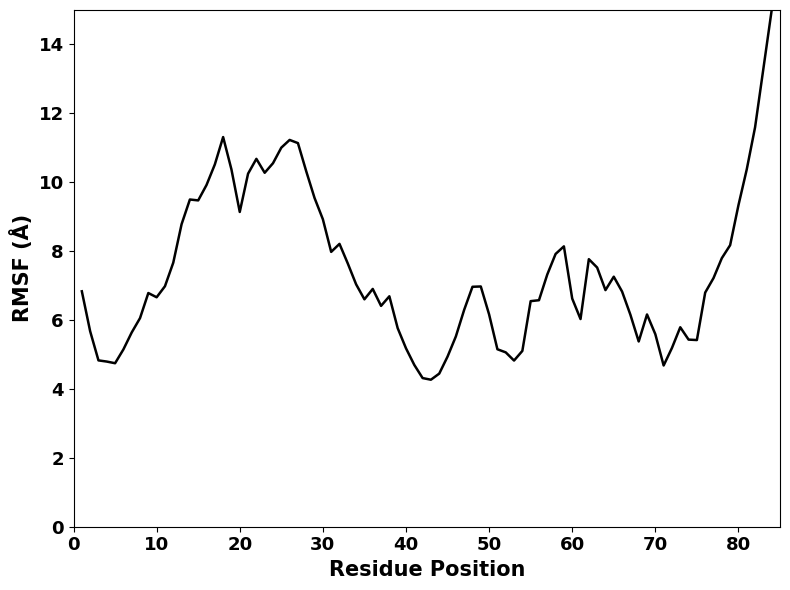

✓ DB1_output/DB1_pub_rmsf.png


In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(ca_resids_ref, rmsf_data["bound_start"]["rmsf"],
        color="black", linewidth=1.8)

ax.set_xlabel("Residue Position", fontsize=15)
ax.set_ylabel("RMSF (Å)",     fontsize=15)
ax.tick_params(labelsize=13)
ax.set_xlim(ca_resids_ref[0] - 1, ca_resids_ref[-1] + 1)
ax.set_ylim(0, 15)   # adjust if your DB1 data exceeds this range

bold_ticks(ax)
plt.tight_layout()
plt.savefig(f"{OUT_PREFIX}_pub_rmsf.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ {OUT_PREFIX}_pub_rmsf.png")


## 6. Equilibration trace — RMSD$_\text{bound}$ − RMSD$_\text{unbound}$


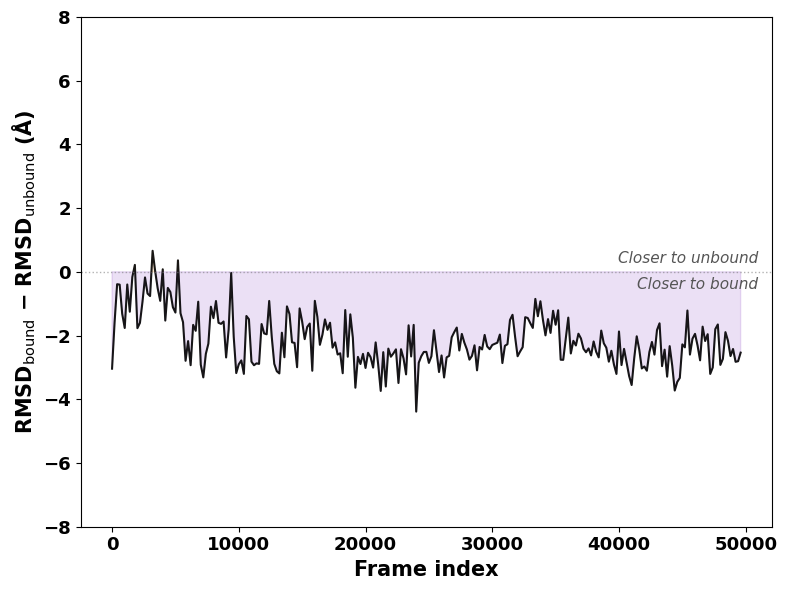

✓ DB1_output/DB1_pub_equilibration.png


In [9]:
tdata = all_data["bound_start"]
n_fr  = tdata["n_frames"]
delta = tdata["rmsd_bound"] - tdata["rmsd_alone"]

n_blocks    = n_fr // BLOCK_SIZE
block_means = np.array([delta[i * BLOCK_SIZE:(i + 1) * BLOCK_SIZE].mean()
                         for i in range(n_blocks)])
block_x     = np.arange(n_blocks) * BLOCK_SIZE

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(block_x, block_means, color="black", linewidth=1.5, alpha=0.9)
ax.fill_between(block_x, block_means, 0, where=block_means >= 0,
                alpha=0.15, color="#FF8C00", interpolate=True)
ax.fill_between(block_x, block_means, 0, where=block_means < 0,
                alpha=0.15, color="#7B2FBE", interpolate=True)
ax.axhline(0, color="gray", ls=":", lw=1, alpha=0.6)

ax.annotate("Closer to unbound", xy=(0.98, 0), xycoords=("axes fraction", "data"),
            fontsize=11, ha="right", va="bottom", fontstyle="italic", color="#555555",
            xytext=(0, 4), textcoords="offset points")
ax.annotate("Closer to bound", xy=(0.98, 0), xycoords=("axes fraction", "data"),
            fontsize=11, ha="right", va="top", fontstyle="italic", color="#555555",
            xytext=(0, -4), textcoords="offset points")

ax.set_xlabel("Frame index", fontsize=15)
ax.set_ylabel(XLAB_DELTA,    fontsize=15)
ax.tick_params(labelsize=13)
ax.set_ylim(-8, 8)   # adjust if your DB1 data exceeds this range

bold_ticks(ax)
plt.tight_layout()
plt.savefig(f"{OUT_PREFIX}_pub_equilibration.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ {OUT_PREFIX}_pub_equilibration.png")


## 7. K-means clustering

In [10]:
# ── Build feature matrix ────────────────────────────────────────────────────
tdata_b = all_data["bound_start"]
eq_b    = tdata_b["eq_mask"]
n_eq_b  = tdata_b["n_eq"]

X = rmsf_data["bound_start"]["ca_positions"].reshape(n_eq_b, -1)
print(f"Feature matrix: {X.shape}")

# ── Elbow analysis ──────────────────────────────────────────────────────────
inertia_vals = []
print("\nEvaluating k=2..15...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia_vals.append(km.inertia_)
    print(f"  k={k:>2d}, inertia={km.inertia_:.0f}")


def find_elbow(inertia_vals, k_vals):
    """Furthest-point-from-secant elbow detection."""
    x = np.array(k_vals, dtype=float)
    y = np.array(inertia_vals, dtype=float)
    x_n = (x - x[0]) / (x[-1] - x[0])
    y_n = (y - y[-1]) / (y[0] - y[-1])
    dists = np.abs(x_n + y_n - 1) / np.sqrt(2)
    return k_vals[np.argmax(dists)]


K_CHOSEN = K_OVERRIDE if K_OVERRIDE is not None else find_elbow(inertia_vals, K_RANGE)
src = "user override" if K_OVERRIDE is not None else "elbow detection"
print(f"\nk = {K_CHOSEN} ({src})")

# ── Final clustering + ordering by mean ΔRMSD ──────────────────────────────
km_final   = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10)
raw_labels = km_final.fit_predict(X)

delta_rmsd_eq = tdata_b["rmsd_bound"][eq_b] - tdata_b["rmsd_alone"][eq_b]
mean_delta = {cl: delta_rmsd_eq[raw_labels == cl].mean() for cl in range(K_CHOSEN)}
sorted_cl  = sorted(mean_delta, key=mean_delta.get)
remap      = {old: new for new, old in enumerate(sorted_cl)}
labels     = np.array([remap[l] for l in raw_labels])
counts     = Counter(labels)

max_pop = max(counts.values()) / n_eq_b

print(f"\n{'Cluster':>10} {'Pop':>7} {'ΔG':>8} {'ΔRMSD':>8} "
      f"{'RMSD_bound':>12} {'RMSD_unbound':>14}")
for cl in sorted(counts):
    mask = labels == cl
    pct  = counts[cl] / n_eq_b
    dG   = -kT * np.log(pct / max_pop)
    bf   = tdata_b["rmsd_bound"][eq_b][mask].mean()
    af   = tdata_b["rmsd_alone"][eq_b][mask].mean()
    dr   = delta_rmsd_eq[mask].mean()
    print(f"  Cluster {cl + 1:>2d} {pct:>6.1%} {dG:>7.2f} {dr:>+7.2f}  "
          f"{bf:>10.2f} Å {af:>12.2f} Å")


Feature matrix: (44999, 252)

Evaluating k=2..15...
  k= 2, inertia=182409753
  k= 3, inertia=158007653
  k= 4, inertia=141837517
  k= 5, inertia=131099625
  k= 6, inertia=120205341
  k= 7, inertia=110253330
  k= 8, inertia=104469022
  k= 9, inertia=99695372
  k=10, inertia=95572112
  k=11, inertia=90823135
  k=12, inertia=84764339
  k=13, inertia=82529624
  k=14, inertia=79459828
  k=15, inertia=76838872

k = 7 (elbow detection)

   Cluster     Pop       ΔG    ΔRMSD   RMSD_bound   RMSD_unbound
  Cluster  1  29.4%   -0.00   -4.71        8.36 Å        13.08 Å
  Cluster  2   6.2%    0.92   -4.47       10.25 Å        14.72 Å
  Cluster  3  10.9%    0.58   -2.47       11.73 Å        14.21 Å
  Cluster  4  14.3%    0.43   -2.41        7.70 Å        10.10 Å
  Cluster  5  11.8%    0.54   -0.94       10.21 Å        11.15 Å
  Cluster  6  18.9%    0.26   +0.11        8.42 Å         8.30 Å
  Cluster  7   8.4%    0.74   +0.84       11.56 Å        10.72 Å


## 8. Cluster scatter plot

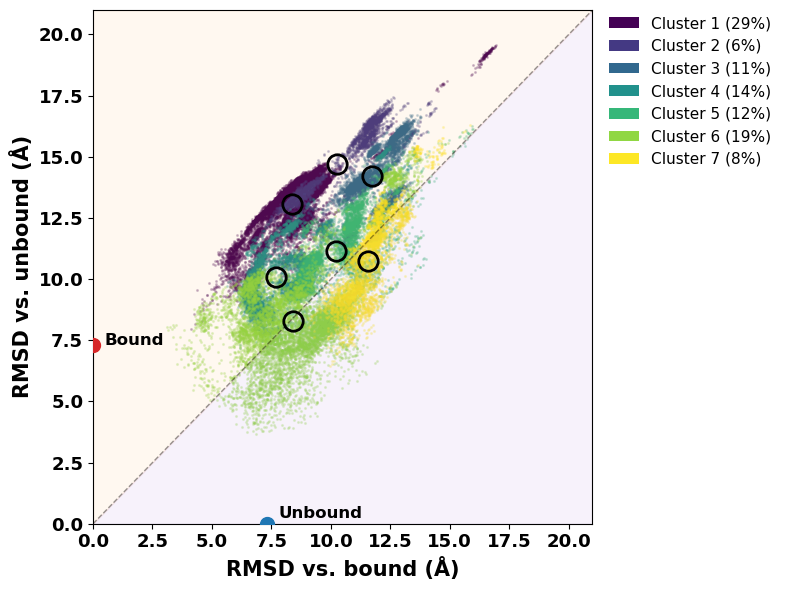

✓ DB1_output/DB1_pub_clusters.png


In [11]:
viridis = plt.cm.viridis
ccolors = {cl: viridis(cl / max(K_CHOSEN - 1, 1)) for cl in range(K_CHOSEN)}

x = tdata_b["rmsd_bound"][eq_b]
y = tdata_b["rmsd_alone"][eq_b]

# Adaptive plot range (round up so axes have a bit of headroom)
xy_max = float(np.ceil(max(x.max(), y.max(), refref_rmsd) + 1))

fig, ax = plt.subplots(figsize=(8, 6))

# Per-cluster scatter (rasterized)
for cl in sorted(counts):
    cl_mask = labels == cl
    ax.scatter(x[cl_mask], y[cl_mask], c=[ccolors[cl]],
               s=1.5, alpha=0.2, rasterized=True)

# Centroids (black outline, no fill)
for cl in sorted(counts):
    cl_mask = labels == cl
    cx, cy  = x[cl_mask].mean(), y[cl_mask].mean()
    ax.plot(cx, cy, "o", markerfacecolor="none", markeredgecolor="black",
            markeredgewidth=2, markersize=14, zorder=5)

# Diagonal + half-plane shading
ax.set_xlim(0, xy_max); ax.set_ylim(0, xy_max)
ax.plot([0, xy_max], [0, xy_max], "k--", alpha=0.4, lw=1)
ax.fill_between([0, xy_max], [0, xy_max], [xy_max, xy_max],
                alpha=0.06, color="#FF8C00")
ax.fill_between([0, xy_max], [0, 0], [0, xy_max],
                alpha=0.06, color="#7B2FBE")

# Reference markers
ax.plot(0, refref_rmsd, "o", color="#d62728", markersize=10, zorder=6)
ax.annotate("Bound", (0, refref_rmsd), fontsize=12, fontweight="bold", ha="left",
            xytext=(8, 0), textcoords="offset points")
ax.plot(refref_rmsd, 0, "o", color="#1f77b4", markersize=10, zorder=6)
ax.annotate("Unbound", (refref_rmsd, 0), fontsize=12, fontweight="bold", ha="left",
            xytext=(8, 4), textcoords="offset points")

ax.set_xlabel("RMSD vs. bound (Å)",   fontsize=15)
ax.set_ylabel("RMSD vs. unbound (Å)", fontsize=15)
ax.tick_params(labelsize=13)

legend_handles = [Patch(facecolor=ccolors[cl], edgecolor="none",
                        label=f"Cluster {cl + 1} ({100.0 * counts[cl] / n_eq_b:.0f}%)")
                  for cl in sorted(counts)]
ax.legend(handles=legend_handles, fontsize=11,
          loc="upper left", bbox_to_anchor=(1.02, 1.0),
          frameon=False, borderaxespad=0)

bold_ticks(ax)
plt.tight_layout()
plt.savefig(f"{OUT_PREFIX}_pub_clusters.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ {OUT_PREFIX}_pub_clusters.png")


## 9. Representative PDBs

In [12]:
u  = universes["bound_start"]
eq_indices_b = np.where(eq_b)[0]

# Compute centroids in feature space (one row per cluster)
centroids = np.zeros((K_CHOSEN, X.shape[1]))
for cl in range(K_CHOSEN):
    centroids[cl] = X[labels == cl].mean(axis=0)

print(f"\n{'Cluster':>10} {'Frame':>8}   {'RMSD_bound':>11} {'RMSD_unbound':>13}")
print("─" * 50)

rep_frames = {}
for cl in sorted(counts):
    cl_mask    = labels == cl
    cl_coords  = X[cl_mask]
    cl_frames  = eq_indices_b[cl_mask]
    d          = np.linalg.norm(cl_coords - centroids[cl], axis=1)
    rep_frame  = int(cl_frames[np.argmin(d)])
    rep_frames[cl] = rep_frame

    bf = tdata_b["rmsd_bound"][rep_frame]
    af = tdata_b["rmsd_alone"][rep_frame]
    print(f"  Cluster {cl + 1:>2d} {rep_frame:>8d}   {bf:>10.2f}Å {af:>12.2f}Å")

# ── Write PDBs ──────────────────────────────────────────────────────────────
print("\nSaving backbone-only representatives...")
for cl, rep_frame in rep_frames.items():
    u.trajectory[rep_frame]
    pdb = f"{OUT_PREFIX}_cluster{cl + 1}_representative.pdb"
    u.select_atoms(TRAJ_SEL).write(pdb)
    pct = 100.0 * counts[cl] / n_eq_b
    print(f"  Cluster {cl + 1} ({pct:.0f}%): {pdb}")

print("\nSaving all-atom representatives...")
for cl, rep_frame in rep_frames.items():
    u.trajectory[rep_frame]
    pdb = f"{OUT_PREFIX}_cluster{cl + 1}_representative_allatom.pdb"
    u.atoms.write(pdb)
    print(f"  Cluster {cl + 1}: {pdb}")

print("\nDone! Load in PyMOL:")
print(f"  pymol {OUT_PREFIX}_cluster*_representative_allatom.pdb")



   Cluster    Frame    RMSD_bound  RMSD_unbound
──────────────────────────────────────────────────
  Cluster  1    11533         7.01Å        12.57Å
  Cluster  2    13299         7.91Å        12.99Å
  Cluster  3    38437        11.68Å        13.81Å
  Cluster  4    34087         7.07Å         9.68Å
  Cluster  5    49581         8.64Å        10.00Å
  Cluster  6    47805         7.34Å         6.69Å
  Cluster  7    10547        10.88Å         9.48Å

Saving backbone-only representatives...
  Cluster 1 (29%): DB1_output/DB1_cluster1_representative.pdb
  Cluster 2 (6%): DB1_output/DB1_cluster2_representative.pdb
  Cluster 3 (11%): DB1_output/DB1_cluster3_representative.pdb
  Cluster 4 (14%): DB1_output/DB1_cluster4_representative.pdb


/home/dbritton/miniforge3/envs/rla/lib/python3.9/site-packages/MDAnalysis/coordinates/PDB.py:1153: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn("Found no information for attr: '{}'"


  Cluster 5 (12%): DB1_output/DB1_cluster5_representative.pdb
  Cluster 6 (19%): DB1_output/DB1_cluster6_representative.pdb
  Cluster 7 (8%): DB1_output/DB1_cluster7_representative.pdb

Saving all-atom representatives...
  Cluster 1: DB1_output/DB1_cluster1_representative_allatom.pdb
  Cluster 2: DB1_output/DB1_cluster2_representative_allatom.pdb
  Cluster 3: DB1_output/DB1_cluster3_representative_allatom.pdb
  Cluster 4: DB1_output/DB1_cluster4_representative_allatom.pdb
  Cluster 5: DB1_output/DB1_cluster5_representative_allatom.pdb
  Cluster 6: DB1_output/DB1_cluster6_representative_allatom.pdb
  Cluster 7: DB1_output/DB1_cluster7_representative_allatom.pdb

Done! Load in PyMOL:
  pymol DB1_output/DB1_cluster*_representative_allatom.pdb
